In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots look cleaner
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [4]:
classes = (
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)

print(classes)

('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [5]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 170M/170M [29:19<00:00, 96.9kB/s]


In [6]:
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Training images: 50000
Testing images: 10000


In [7]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", classes[label])

Image shape: torch.Size([3, 32, 32])
Label: 6
Class: frog


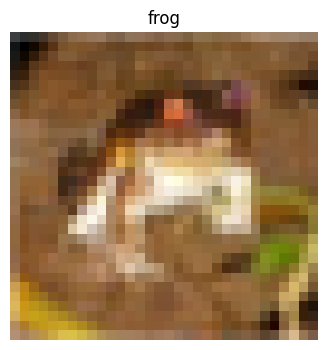

In [8]:
plt.figure(figsize=(4, 4))

plt.imshow(image.permute(1, 2, 0))
plt.title(classes[label])
plt.axis("off")

plt.show()

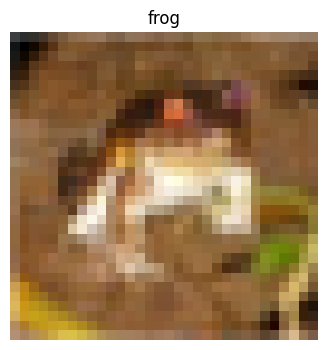

In [9]:
plt.figure(figsize=(4, 4))

plt.imshow(image.permute(1, 2, 0))
plt.title(classes[label])
plt.axis("off")

plt.show()

In [10]:
image.permute(1, 2, 0)

tensor([[[0.2314, 0.2431, 0.2471],
         [0.1686, 0.1804, 0.1765],
         [0.1961, 0.1882, 0.1686],
         ...,
         [0.6196, 0.5176, 0.4235],
         [0.5961, 0.4902, 0.4000],
         [0.5804, 0.4863, 0.4039]],

        [[0.0627, 0.0784, 0.0784],
         [0.0000, 0.0000, 0.0000],
         [0.0706, 0.0314, 0.0000],
         ...,
         [0.4824, 0.3451, 0.2157],
         [0.4667, 0.3255, 0.1961],
         [0.4784, 0.3412, 0.2235]],

        [[0.0980, 0.0941, 0.0824],
         [0.0627, 0.0275, 0.0000],
         [0.1922, 0.1059, 0.0314],
         ...,
         [0.4627, 0.3294, 0.1961],
         [0.4706, 0.3294, 0.1961],
         [0.4275, 0.2863, 0.1647]],

        ...,

        [[0.8157, 0.6667, 0.3765],
         [0.7882, 0.6000, 0.1333],
         [0.7765, 0.6314, 0.1020],
         ...,
         [0.6275, 0.5216, 0.2745],
         [0.2196, 0.1216, 0.0275],
         [0.2078, 0.1333, 0.0784]],

        [[0.7059, 0.5451, 0.3765],
         [0.6784, 0.4824, 0.1647],
         [0.

In [11]:
transforms.ToTensor()

ToTensor()

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [13]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])


In [16]:
class CIFARClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.network(x)
        return x

In [17]:
model = CIFARClassifier().to(device)

print(model)

CIFARClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [20]:
print("Input image: 3 × 32 × 32")
print("Flatten: 3072 values")
print("Linear: 3072 → 512")
print("ReLU")
print("Linear: 512 → 256")
print("ReLU")
print("Linear: 256 → 128")
print("ReLU")
print("Linear: 128 → 10")
print("Output: 10 logits")
print("Softmax: 10 probabilities")

Input image: 3 × 32 × 32
Flatten: 3072 values
Linear: 3072 → 512
ReLU
Linear: 512 → 256
ReLU
Linear: 256 → 128
ReLU
Linear: 128 → 10
Output: 10 logits
Softmax: 10 probabilities


In [19]:
image, label = train_dataset[0]

image = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    logits = model(image)

print("Raw logits:")
print(logits)


Raw logits:
tensor([[ 0.0012, -0.0727,  0.1186,  0.0305, -0.0535,  0.0393, -0.0480,  0.0877,
          0.1407, -0.0621]])


In [21]:
probabilities = torch.softmax(logits, dim=1)

print("Probabilities:")
print(probabilities)

Probabilities:
tensor([[0.0980, 0.0911, 0.1103, 0.1010, 0.0928, 0.1019, 0.0933, 0.1069, 0.1127,
         0.0920]])


In [22]:
print("Probability sum:", probabilities.sum().item())

Probability sum: 0.9999999403953552


In [23]:
prediction = torch.argmax(probabilities, dim=1)

print("Predicted class index:", prediction.item())
print("Predicted class:", classes[prediction.item()])
print("Actual class:", classes[label])

Predicted class index: 8
Predicted class: ship
Actual class: frog


In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [26]:
num_epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] Loss: 1.6680 Accuracy: 40.80%
Epoch [2/10] Loss: 1.4574 Accuracy: 48.43%
Epoch [3/10] Loss: 1.3468 Accuracy: 52.30%
Epoch [4/10] Loss: 1.2636 Accuracy: 55.31%
Epoch [5/10] Loss: 1.1893 Accuracy: 57.88%
Epoch [6/10] Loss: 1.1154 Accuracy: 60.32%
Epoch [7/10] Loss: 1.0519 Accuracy: 62.43%
Epoch [8/10] Loss: 0.9854 Accuracy: 64.86%
Epoch [9/10] Loss: 0.9285 Accuracy: 66.62%
Epoch [10/10] Loss: 0.8780 Accuracy: 68.27%


In [27]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 52.94%


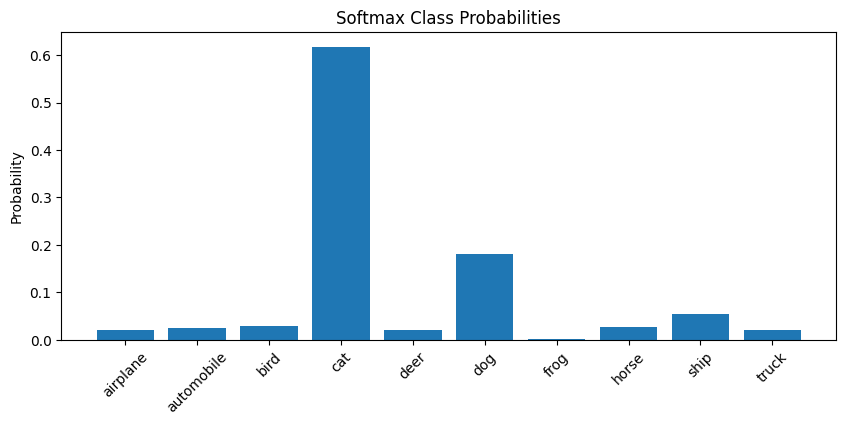

In [30]:
index = 0

plt.figure(figsize=(10, 4))

plt.bar(classes, probabilities[index].cpu().numpy())

plt.xticks(rotation=45)
plt.ylabel("Probability")
plt.title("Softmax Class Probabilities")

plt.show()

In [28]:
def denormalize(image):

    mean = torch.tensor(
        [0.4914, 0.4822, 0.4465]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.2470, 0.2435, 0.2616]
    ).view(3, 1, 1)

    image = image.cpu() * std + mean

    return image

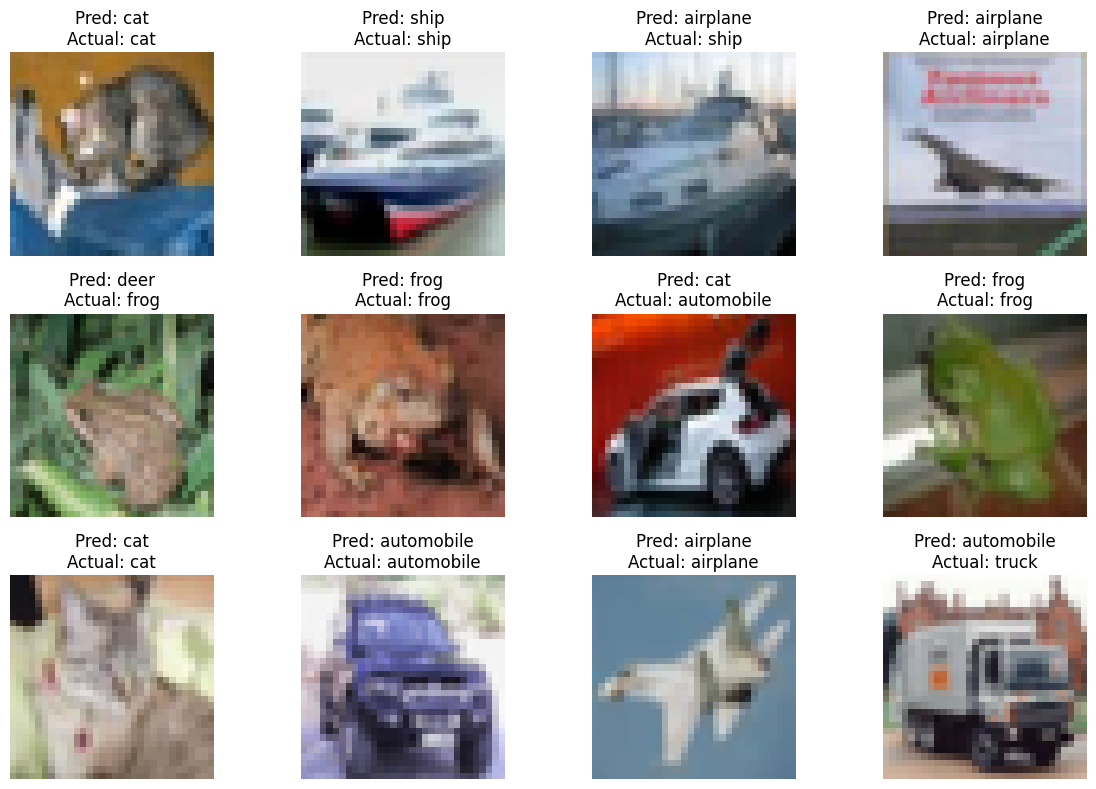

In [29]:
model.eval()

images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    probabilities = torch.softmax(outputs, dim=1)
    predictions = torch.argmax(probabilities, dim=1)

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    img = denormalize(images[i])
    img = img.permute(1, 2, 0)

    plt.imshow(img)
    plt.title(
        f"Pred: {classes[predictions[i]]}\n"
        f"Actual: {classes[labels[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

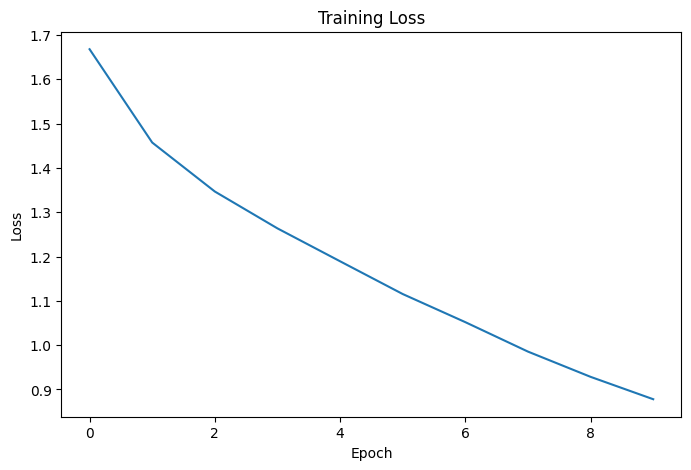

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

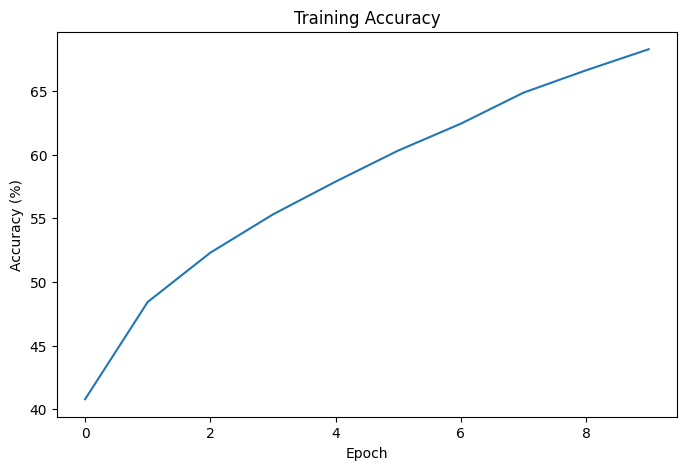

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')